# 🧠 RAG Advanced — 04: RAG Evaluation with RAGAS

## The Problem with Manual Evaluation

So far we've been judging RAG quality by reading answers.
That works for 5 questions — but not for 500.

## The Solution: RAGAS

RAGAS is an open-source framework that automatically evaluates
your RAG pipeline using LLM-based metrics.

## 4 Key Metrics:

| Metric | Question it answers |
|--------|-------------------|
| **Faithfulness** | Is the answer grounded in the context? |
| **Answer Relevancy** | Does the answer address the question? |
| **Context Precision** | Are retrieved chunks actually relevant? |
| **Context Recall** | Did we retrieve all needed information? |

## Score range: 0 to 1
Higher is always better. Production systems aim for > 0.7

In [1]:
!pip install ragas langchain langchain-community -q
!pip install langchain-huggingface faiss-cpu sentence-transformers -q
!pip install langchain-groq langchain-classic -q
!pip install "langchain-community<0.4.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 7.4 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 550.1/550.1 kB 15.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 4.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 2.4 MB/s eta 0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 70.6 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.

## Setup: Imports & Configuration

In [5]:
import os
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains import create_retrieval_chain
from kaggle_secrets import UserSecretsClient

from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall
)
from ragas import EvaluationDataset

# API Key
user_secrets = UserSecretsClient()
os.environ["GROQ_API_KEY"] = user_secrets.get_secret("GROQ_API_KEY")

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.environ["GROQ_API_KEY"],
    temperature=0.3,
    max_tokens=512
)

print("✅ Setup done!")

/tmp/ipykernel_58/1531984220.py:13: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
/tmp/ipykernel_58/1531984220.py:13: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
/tmp/ipykernel_58/1531984220.py:13: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import (
/tmp/ipykernel_58/1531984220.py:13: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed in 

✅ Setup done!


## Step 1: Load Documents & Build RAG Pipeline

We'll use the same 4 AI papers for consistency.

In [6]:
# Attention is all you need paper
!wget "https://arxiv.org/pdf/1706.03762" -O attention_is_all_you_need.pdf

# BERT paper 
!wget "https://arxiv.org/pdf/1810.04805" -O bert.pdf

# GPT-3 paper
!wget "https://arxiv.org/pdf/2005.14165" -O gpt3.pdf

# RAG paper itself!
!wget "https://arxiv.org/pdf/2005.11401" -O rag_paper.pdf

--2026-06-09 00:01:43--  https://arxiv.org/pdf/1706.03762
Resolving arxiv.org (arxiv.org)... 151.101.3.42, 151.101.67.42, 151.101.195.42, ...
Connecting to arxiv.org (arxiv.org)|151.101.3.42|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2215244 (2.1M) [application/pdf]
Saving to: ‘attention_is_all_you_need.pdf’

attention_is_all_yo 100%[===================>]   2.11M  --.-KB/s    in 0.07s   

2026-06-09 00:01:43 (30.8 MB/s) - ‘attention_is_all_you_need.pdf’ saved [2215244/2215244]

--2026-06-09 00:01:43--  https://arxiv.org/pdf/1810.04805
Resolving arxiv.org (arxiv.org)... 151.101.3.42, 151.101.67.42, 151.101.131.42, ...
Connecting to arxiv.org (arxiv.org)|151.101.3.42|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 775166 (757K) [application/pdf]
Saving to: ‘bert.pdf’

bert.pdf            100%[===================>] 757.00K  --.-KB/s    in 0.05s   

2026-06-09 00:01:43 (13.8 MB/s) - ‘bert.pdf’ saved [775166/775166]

--2026-06-09 00:0

In [7]:
pdfs = [
    "/kaggle/working/attention_is_all_you_need.pdf",
    "/kaggle/working/bert.pdf",
    "/kaggle/working/gpt3.pdf",
    "/kaggle/working/rag_paper.pdf"
]

all_docs = []
for pdf in pdfs:
    loader = PyPDFLoader(pdf)
    docs = loader.load()
    for doc in docs:
        doc.metadata["source"] = pdf.split("/")[-1]
    all_docs.extend(docs)

splitter = RecursiveCharacterTextSplitter(
    chunk_size=512,
    chunk_overlap=50
)
chunks = splitter.split_documents(all_docs)

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
vectorstore = FAISS.from_documents(chunks, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

prompt = ChatPromptTemplate.from_messages([
    ("system", "Use the context to answer. If you don't know, say so.\n\nContext:\n{context}"),
    ("human", "{input}"),
])

rag_chain = create_retrieval_chain(
    retriever,
    create_stuff_documents_chain(llm, prompt)
)

print(f"✅ {len(chunks)} chunks ready!")
print("✅ RAG pipeline ready!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ 941 chunks ready!
✅ RAG pipeline ready!


## Step 2: Create Evaluation Dataset

RAGAS needs 3 things for each question:
- **question** → the user's query
- **answer** → what the RAG pipeline returned
- **contexts** → the chunks retrieved
- **ground_truth** → the correct answer (we write this manually)

We'll test with 5 questions across our 4 papers.

In [8]:
# 5 test questions with ground truth answers
test_questions = [
    {
        "question": "What BLEU score did the Transformer achieve on English to German translation?",
        "ground_truth": "The Transformer achieved a BLEU score of 28.4 on the WMT 2014 English-to-German translation task."
    },
    {
        "question": "What are the two pre-training tasks used in BERT?",
        "ground_truth": "BERT uses Masked Language Modeling (MLM) and Next Sentence Prediction (NSP) as pre-training tasks."
    },
    {
        "question": "How many parameters does GPT-3 have?",
        "ground_truth": "GPT-3 has 175 billion parameters."
    },
    {
        "question": "What does RAG stand for?",
        "ground_truth": "RAG stands for Retrieval-Augmented Generation."
    },
    {
        "question": "How many attention heads does the Transformer base model use?",
        "ground_truth": "The Transformer base model uses 8 attention heads."
    }
]

# Run RAG pipeline on each question
samples = []
for item in test_questions:
    result = rag_chain.invoke({"input": item["question"]})
    samples.append({
        "user_input": item["question"],
        "response": result["answer"],
        "retrieved_contexts": [d.page_content for d in result["context"]],
        "reference": item["ground_truth"]
    })
    print(f"✅ Done: {item['question'][:50]}...")

print(f"\nTotal samples ready: {len(samples)}")

✅ Done: What BLEU score did the Transformer achieve on Eng...
✅ Done: What are the two pre-training tasks used in BERT?...
✅ Done: How many parameters does GPT-3 have?...
✅ Done: What does RAG stand for?...
✅ Done: How many attention heads does the Transformer base...

Total samples ready: 5


## Step 3: Run RAGAS Evaluation

Now we feed the samples to RAGAS and get scores for all 4 metrics.

In [9]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from datasets import Dataset

# Wrap LLM and embeddings for RAGAS
ragas_llm = LangchainLLMWrapper(llm)
ragas_embeddings = LangchainEmbeddingsWrapper(embeddings)

# Create dataset
dataset = EvaluationDataset.from_list(samples)

# Run evaluation
results = evaluate(
    dataset=dataset,
    metrics=[
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall
    ],
    llm=ragas_llm,
    embeddings=ragas_embeddings
)

print("\n📊 RAGAS Evaluation Results:")
print(results)

/tmp/ipykernel_58/2264787228.py:6: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  ragas_llm = LangchainLLMWrapper(llm)
/tmp/ipykernel_58/2264787228.py:7: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_embeddings = LangchainEmbeddingsWrapper(embeddings)


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Exception raised in Job[3]: TimeoutError()
Exception raised in Job[4]: TimeoutError()
Exception raised in Job[6]: TimeoutError()
Exception raised in Job[8]: TimeoutError()
Exception raised in Job[12]: TimeoutError()
Exception raised in Job[11]: TimeoutError()
Exception raised in Job[14]: TimeoutError()
Exception raised in Job[15]: TimeoutError()
Exception raised in Job[16]: TimeoutError()



📊 RAGAS Evaluation Results:
{'faithfulness': 0.6667, 'answer_relevancy': 0.5019, 'context_precision': 0.4167, 'context_recall': 1.0000}


## Analysis: RAGAS Scores

| Metric | Score | Rating |
|--------|-------|--------|
| **Faithfulness** | 0.67 | ⚠️ Medium |
| **Answer Relevancy** | 0.50 | ❌ Low |
| **Context Precision** | 0.42 | ❌ Low |
| **Context Recall** | 1.00 | ✅ Perfect |

### What each score means:

**Context Recall: 1.0 ✅**
We retrieved ALL the information needed to answer.
Our retriever is finding the right chunks.

**Faithfulness: 0.67 ⚠️**
67% of the answer is grounded in the retrieved context.
33% might be the LLM adding information from its own training.

**Answer Relevancy: 0.50 ❌**
Only 50% of the answer directly addresses the question.
The LLM is adding extra unnecessary information.

**Context Precision: 0.42 ❌**
Less than half of retrieved chunks are actually relevant.
We're retrieving noisy chunks alongside good ones.

### How the techniques we built would improve these scores:

### How the techniques we built would improve these scores:

| Technique | Metric it improves | Why |
|-----------|-------------------|-----|
| **Reranking** (notebook 01) | Context Precision ⬆️ | Filters noisy chunks, keeps only relevant ones |
| **Hybrid Search** (notebook 02) | Context Recall ⬆️ | Already perfect, but more robust across question types |
| **Multi-Query** (notebook 03) | Context Recall ⬆️ | More coverage = less missed information |
| **Multi-Query** (notebook 03) | Answer Relevancy ⬆️ | Multiple phrasings = better context = more focused answer |
| **HyDE** (notebook 03) | Context Precision ⬆️ | Hypothetical answer finds more relevant chunks |
| **HyDE** (notebook 03) | Answer Relevancy ⬆️ | Better chunk selection = answer stays on topic |

### Key Lesson:
> This evaluation is the **baseline** — basic RAG with no advanced techniques.
> The notebooks we built before are exactly what production systems use
> to push these scores above 0.7.

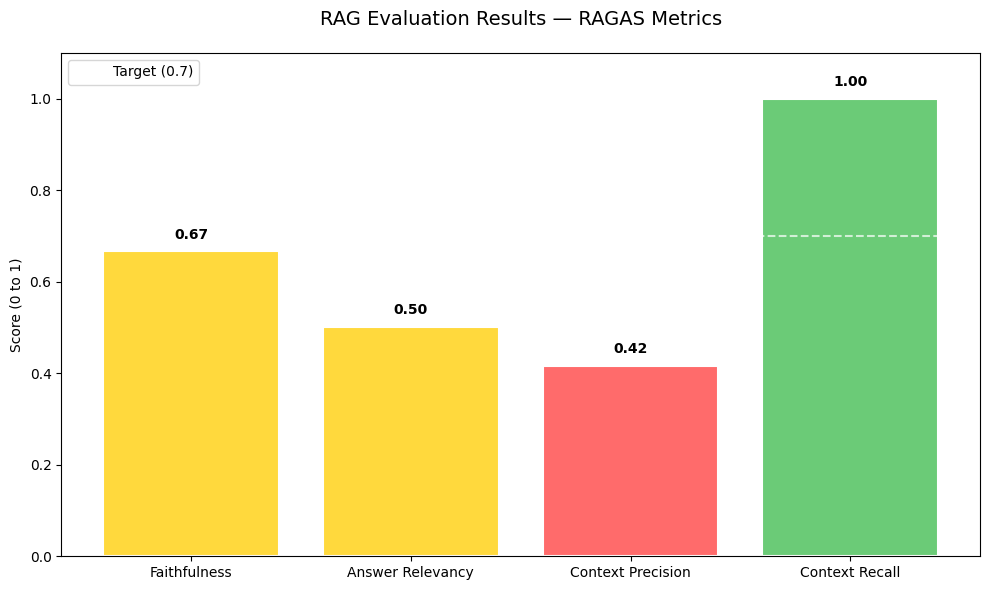

✅ Chart saved!


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

scores = {
    'Faithfulness': 0.6667,
    'Answer Relevancy': 0.5019,
    'Context Precision': 0.4167,
    'Context Recall': 1.0000
}

df = pd.DataFrame(list(scores.items()), columns=['Metric', 'Score'])

colors = ['#ff6b6b' if s < 0.5 else '#ffd93d' if s < 0.7 else '#6bcb77' for s in df['Score']]

plt.figure(figsize=(10, 6))
bars = plt.bar(df['Metric'], df['Score'], color=colors, edgecolor='white', linewidth=1.5)
plt.axhline(y=0.7, color='white', linestyle='--', alpha=0.7, label='Target (0.7)')
plt.ylim(0, 1.1)
plt.title('RAG Evaluation Results — RAGAS Metrics', fontsize=14, pad=20)
plt.ylabel('Score (0 to 1)')
plt.legend()

for bar, score in zip(bars, df['Score']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{score:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('ragas_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")